# Database Construction — Part 2

**Step 2 of 2** — Cleanup, enrichment, and final schema build.

Input: `poi_dataset.csv` (this is the `pois_with_main_sub_multi_v4.csv` produced by Part 1, renamed). It already has the flat `main_1, main_2, sub_1..sub_4` schema.

Pipeline:
1. Inspect category distributions
2. Extract POIs still labelled `"Other"` for manual review
3. Apply manual labels to the reviewed POIs, drop anything still labelled `"Other"`
4. Re-run the distribution check on the cleaned dataset
5. Attach a `city` column by matching each POI's `(lat, lon)` against the per-city JSON files
6. Detect coordinate duplicates, then delete the listed duplicate rows
7. Plot POIs per city
8. Assign a `max_days` visit-budget column based on each city's POI count
9. Estimate per-city min/max travel distance via Monte-Carlo nearest-neighbour routing
10. Merge the distance table into the final CSV

> *Demo notebook — kept for transparency, not intended to be re-run.*

In [ ]:
# Count how many POIs fall into each main and sub category.

import pandas as pd

df = pd.read_csv("/content/poi_dataset.csv")
main_cols = ["main_1", "main_2"]

# Stack both main columns into one series and count every non-null value.
main_counts = (
    df[main_cols]
    .stack()
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

print("\n================ MAIN CATEGORY COUNTS ================\n")
for cat, count in main_counts.items():
    print(f"{cat}: {count}")

print("\nTotal unique main categories:", len(main_counts))

sub_cols = ["sub_1", "sub_2", "sub_3", "sub_4"]

# Same stacking trick for all four sub columns.
sub_counts = (
    df[sub_cols]
    .stack()
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

print("\n================ SUB CATEGORY COUNTS ================\n")
for cat, count in sub_counts.items():
    print(f"{cat}: {count}")

print("\nTotal unique sub categories:", len(sub_counts))


================ MAIN CATEGORY COUNTS ================

Cultural Heritage: 1593
Nature: 1155
Museums: 439
Other: 146

Total unique main categories: 4

================ SUB CATEGORY COUNTS ================

Parks & Outdoor: 592
Ancient & Archaeology: 557
Terrain & Landforms: 545
Museum: 439
Urban & Monumental Heritage: 370
Religious: 341
Fortifications: 319
Water & Coastal: 273
Civil & Traditional Architecture: 259
Other: 146
Transportation as Heritage: 58
Historical Infrastructure: 25
Wildlife & Natural Experience: 10

Total unique sub categories: 13


In [ ]:
# Pull out every POI that still has "Other" in any category slot
# so it can be manually labelled or discarded in the next step.

import pandas as pd

df = pd.read_csv("/content/poi_dataset.csv")

main_cols = ["main_1", "main_2"]
sub_cols = ["sub_1", "sub_2", "sub_3", "sub_4"]

# True for any row where at least one category column equals "Other".
mask = df[main_cols + sub_cols].eq("Other").any(axis=1)

other_rows = df[mask]

print("Total rows containing 'Other':", len(other_rows))

# Dump to a text file for offline review by a human labeller.
with open("other_pois.txt", "w", encoding="utf-8") as f:
    for _, row in other_rows.iterrows():
        name = row.get("name", "Unknown_POI")

        mains = [str(row[c]) for c in main_cols if pd.notna(row[c])]
        subs  = [str(row[c]) for c in sub_cols if pd.notna(row[c])]

        f.write(f"{name}\n")
        f.write(f"  Main: {', '.join(mains)}\n")
        f.write(f"  Sub : {', '.join(subs)}\n")
        f.write("\n")

print("Saved to other_pois.txt")

Total rows containing 'Other': 146
Saved to other_pois.txt


### Manually labelled POIs

The list below is the human-curated label set for every POI that ended up with an `"Other"` tag. These labels are applied in the next code cell.

```
Kula-Salihli UNESCO Global Jeoparkı --
Main: Nature
Sub: Terrain & Landforms

Kars Osmanlı Rus Mevzileri --
Main: Cultural Heritage
Sub: Fortifications

Trabzon Ayasofya (Hagia Sophia) --
Main: Cultural Heritage
Sub: Religious, Urban & Monumental Heritage

Ali Kayası Cam Terası --
Main: Nature
Sub: Parks & Outdoor, Terrain & Landforms

Salih Ağa Kasteli --
Main: Cultural Heritage
Sub: Historical Infrastructure, Civil & Traditional Architecture

Atakule --
Main: Cultural Heritage
Sub: Urban & Monumental Heritage

CerModern --
Main: Museums
Sub: Museum

Atatürk Orman Çiftliği --
Main: Nature, Cultural Heritage
Sub: Parks & Outdoor, Civil & Traditional Architecture

İstiklal Şehitliği --
Main: Cultural Heritage
Sub: Urban & Monumental Heritage

Gazi Köşkü --
Main: Cultural Heritage
Sub: Civil & Traditional Architecture

Kefken Pembe Kayalar --
Main: Nature
Sub: Terrain & Landforms

Karasu Nehri --
Main: Nature
Sub: Water & Coastal

Atakum Sahili --
Main: Nature
Sub: Water & Coastal, Parks & Outdoor

Safranbolu --
Main: Cultural Heritage
Sub: Civil & Traditional Architecture, Urban & Monumental Heritage

Yenice Ormanları --
Main: Nature
Sub: Parks & Outdoor, Wildlife & Natural Experience

Hattuşa (Boğazköy) - Hitit Başkenti --
Main: Cultural Heritage
Sub: Ancient & Archaeology, Urban & Monumental Heritage

Meryem Ana Kaya Tapınağı --
Main: Cultural Heritage
Sub: Religious, Ancient & Archaeology

Taşkale Tahıl Ambarları --
Main: Cultural Heritage
Sub: Civil & Traditional Architecture, Historical Infrastructure

Gökçedere Höyüğü --
Main: Cultural Heritage
Sub: Ancient & Archaeology

Örme Dikilitaş --
Main: Cultural Heritage
Sub: Ancient & Archaeology, Urban & Monumental Heritage

Süleyman Paşa Sarayı --
Main: Cultural Heritage
Sub: Civil & Traditional Architecture

Tarihi Osman Paşa Şadırvanı --
Main: Cultural Heritage
Sub: Civil & Traditional Architecture, Historical Infrastructure
```

In [ ]:
# Write the curated labels back into the dataframe, then drop every
# row that still has "Other" anywhere — those didn't make it through review.

import pandas as pd

df = pd.read_csv("/content/poi_dataset.csv")

# Hand-curated labels for the POIs that were flagged as "Other" in the
# previous cell. Keys are POI names; values give the new main/sub lists.
labels = {

"Kula-Salihli UNESCO Global Jeoparkı": {
    "main": ["Nature"],
    "sub": ["Terrain & Landforms"]
},

"Kars Osmanlı Rus Mevzileri": {
    "main": ["Cultural Heritage"],
    "sub": ["Fortifications"]
},

"Trabzon Ayasofya (Hagia Sophia)": {
    "main": ["Cultural Heritage"],
    "sub": ["Religious", "Urban & Monumental Heritage"]
},

"Ali Kayası Cam Terası": {
    "main": ["Nature"],
    "sub": ["Parks & Outdoor", "Terrain & Landforms"]
},

"Salih Ağa Kasteli": {
    "main": ["Cultural Heritage"],
    "sub": ["Historical Infrastructure", "Civil & Traditional Architecture"]
},

"Atakule": {
    "main": ["Cultural Heritage"],
    "sub": ["Urban & Monumental Heritage"]
},

"CerModern": {
    "main": ["Museums"],
    "sub": ["Museum"]
},

"Atatürk Orman Çiftliği": {
    "main": ["Nature","Cultural Heritage"],
    "sub": ["Parks & Outdoor","Civil & Traditional Architecture"]
},

"İstiklal Şehitliği": {
    "main": ["Cultural Heritage"],
    "sub": ["Urban & Monumental Heritage"]
},

"Gazi Köşkü": {
    "main": ["Cultural Heritage"],
    "sub": ["Civil & Traditional Architecture"]
},

"Kefken Pembe Kayalar": {
    "main": ["Nature"],
    "sub": ["Terrain & Landforms"]
},

"Karasu Nehri": {
    "main": ["Nature"],
    "sub": ["Water & Coastal"]
},

"Atakum Sahili": {
    "main": ["Nature"],
    "sub": ["Water & Coastal","Parks & Outdoor"]
},

"Safranbolu": {
    "main": ["Cultural Heritage"],
    "sub": ["Civil & Traditional Architecture","Urban & Monumental Heritage"]
},

"Yenice Ormanları": {
    "main": ["Nature"],
    "sub": ["Parks & Outdoor","Wildlife & Natural Experience"]
},

"Hattuşa (Boğazköy) - Hitit Başkenti": {
    "main": ["Cultural Heritage"],
    "sub": ["Ancient & Archaeology","Urban & Monumental Heritage"]
},

"Meryem Ana Kaya Tapınağı": {
    "main": ["Cultural Heritage"],
    "sub": ["Religious","Ancient & Archaeology"]
},

"Taşkale Tahıl Ambarları": {
    "main": ["Cultural Heritage"],
    "sub": ["Civil & Traditional Architecture","Historical Infrastructure"]
},

"Gökçedere Höyüğü": {
    "main": ["Cultural Heritage"],
    "sub": ["Ancient & Archaeology"]
},

"Örme Dikilitaş": {
    "main": ["Cultural Heritage"],
    "sub": ["Ancient & Archaeology","Urban & Monumental Heritage"]
},

"Süleyman Paşa Sarayı": {
    "main": ["Cultural Heritage"],
    "sub": ["Civil & Traditional Architecture"]
},

"Tarihi Osman Paşa Şadırvanı": {
    "main": ["Cultural Heritage"],
    "sub": ["Civil & Traditional Architecture","Historical Infrastructure"]
}
}


# Write the curated values into main_1/main_2 and sub_1..sub_4.
for poi, cats in labels.items():

    mask = df["name"] == poi

    mains = cats.get("main", [])
    subs  = cats.get("sub", [])

    if len(mains) > 0:
        df.loc[mask, "main_1"] = mains[0]

    if len(mains) > 1:
        df.loc[mask, "main_2"] = mains[1]

    # Positionally fill up to 4 sub slots.
    for i, sub in enumerate(subs[:4]):
        df.loc[mask, f"sub_{i+1}"] = sub

cat_cols = [
    "main_1","main_2",
    "sub_1","sub_2","sub_3","sub_4"
]

# Any POI still containing "Other" after manual labelling gets dropped.
mask_other = df[cat_cols].eq("Other").any(axis=1)

deleted = df[mask_other]
cleaned = df[~mask_other]

print("Deleted POIs:", len(deleted))
print("Remaining POIs:", len(cleaned))

# Log the deletions so the removal step is auditable.
with open("deleted_pois.txt", "w", encoding="utf-8") as f:

    for _, row in deleted.iterrows():

        name = row.get("name", "UNKNOWN")

        mains = [
            str(row[c]) for c in ["main_1","main_2"]
            if pd.notna(row[c])
        ]

        subs = [
            str(row[c]) for c in ["sub_1","sub_2","sub_3","sub_4"]
            if pd.notna(row[c])
        ]

        f.write(f"{name}\n")
        f.write(f"  Main: {', '.join(mains)}\n")
        f.write(f"  Sub : {', '.join(subs)}\n\n")

cleaned.to_csv(
    "poi_dataset_cleaned.csv",
    index=False
)

print("Saved:")
print(" - poi_dataset_cleaned.csv")
print(" - deleted_pois.txt")

Deleted POIs: 125
Remaining POIs: 2712
Saved:
 - poi_dataset_cleaned.csv
 - deleted_pois.txt


In [ ]:
# Same category-count report as cell 1, but on the cleaned dataset.
# Confirms that the "Other" bucket is gone after the manual relabelling.

import pandas as pd

df = pd.read_csv("/content/poi_dataset_cleaned.csv")
main_cols = ["main_1", "main_2"]

main_counts = (
    df[main_cols]
    .stack()
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

print("\n================ MAIN CATEGORY COUNTS ================\n")
for cat, count in main_counts.items():
    print(f"{cat}: {count}")

print("\nTotal unique main categories:", len(main_counts))

sub_cols = ["sub_1", "sub_2", "sub_3", "sub_4"]

sub_counts = (
    df[sub_cols]
    .stack()
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

print("\n================ SUB CATEGORY COUNTS ================\n")
for cat, count in sub_counts.items():
    print(f"{cat}: {count}")

print("\nTotal unique sub categories:", len(sub_counts))


================ MAIN CATEGORY COUNTS ================

Cultural Heritage: 1607
Nature: 1162
Museums: 440

Total unique main categories: 3

================ SUB CATEGORY COUNTS ================

Parks & Outdoor: 596
Ancient & Archaeology: 561
Terrain & Landforms: 548
Museum: 440
Urban & Monumental Heritage: 376
Religious: 343
Fortifications: 320
Water & Coastal: 275
Civil & Traditional Architecture: 265
Transportation as Heritage: 58
Historical Infrastructure: 27
Wildlife & Natural Experience: 11

Total unique sub categories: 12


In [ ]:
# Attach a `city` column by looking each POI's (lat, lon) up in the
# per-city JSON files. Each JSON file is named after its city.

import pandas as pd
import json
import os

csv_path = "/content/poi_dataset_cleaned.csv"
cities_dir = "/content/cities"

df = pd.read_csv(csv_path)

# Build a dictionary: (lat, lon) -> city name. Coordinates are rounded
# to 6 decimal places to absorb tiny float noise across sources.
coord_to_city = {}

for file in os.listdir(cities_dir):

    if file.endswith(".json"):

        city = file.replace(".json","")

        path = os.path.join(cities_dir,file)

        with open(path,encoding="utf-8") as f:
            data = json.load(f)

        # Files are either a raw list or a dict wrapping it under "components".
        components = data if isinstance(data,list) else data.get("components",[])

        for comp in components:

            lat = comp.get("lat")
            lon = comp.get("lon")

            if lat and lon:
                coord_to_city[(round(lat,6), round(lon,6))] = city


print("Total coordinates mapped:", len(coord_to_city))

# Look up each row's coordinate pair in the dictionary.
df["city"] = df.apply(
    lambda r: coord_to_city.get(
        (round(r["lat"],6), round(r["lon"],6))
    ),
    axis=1
)

print("Missing city:", df["city"].isna().sum())
print("Total rows:", len(df))


df.to_csv(
    "/content/poi_dataset_with_city.csv",
    index=False
)

print("Saved -> poi_dataset_with_city.csv")

Total coordinates mapped: 2826
Missing city: 0
Total rows: 2712
Saved -> poi_dataset_with_city.csv


In [ ]:
# Scan for rows that share the exact same (lat, lon). These are usually
# POIs that were harvested from more than one source with slightly
# different names but represent the same physical place.

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df = pd.read_csv("/content/poi_dataset_with_city.csv")

# keep=False marks every member of a duplicate group, not just the extras.
duplicates = df[df.duplicated(subset=["lat","lon"], keep=False)]

print("Duplicate coordinate groups:", duplicates[["lat","lon"]].drop_duplicates().shape[0])
print("Total duplicate rows:", len(duplicates))

# Sort by coordinate so duplicate pairs sit next to each other for review.
duplicates.sort_values(["lat","lon"])

Duplicate coordinate groups: 8
Total duplicate rows: 17


,name,lat,lon,categories,main_1,main_2,sub_1,sub_2,sub_3,sub_4,city
1881,Cennet - Cehennem Mağaraları,36.451937,34.106336,['Cave'],Nature,NaN,Terrain & Landforms,NaN,NaN,NaN,Mersin
1893,Cennet ve Cehennem Obrukları,36.451937,34.106336,['Cave'],Nature,NaN,Terrain & Landforms,NaN,NaN,NaN,Mersin
1839,Olba (ancient city),36.583333,33.933333,['Ancient_City'],Cultural Heritage,NaN,Ancient & Archaeology,NaN,NaN,NaN,Mersin
1841,Uzuncaburç (Diokaisareia),36.583333,33.933333,"['Ancient_City', 'Ancient_Structure']",Cultural Heritage,NaN,Ancient & Archaeology,NaN,NaN,NaN,Mersin
2205,Seleucia (Pamphylia),36.874770,31.473440,['Ancient_City'],Cultural Heritage,NaN,Ancient & Archaeology,NaN,NaN,NaN,Antalya
2244,Lyrbe,36.874770,31.473440,['Ancient_City'],Cultural Heritage,NaN,Ancient & Archaeology,NaN,NaN,NaN,Antalya
2148,Taşkale Tahıl Ambarları,37.140046,33.606235,['Other'],Cultural Heritage,NaN,Civil & Traditional Architecture,Historical Infrastructure,NaN,NaN,Karaman
2149,Manazan Mağaraları,37.140046,33.606235,['Cave'],Nature,NaN,Terrain & Landforms,NaN,NaN,NaN,Karaman
117,Bafa Gölü,37.516700,27.450000,['Lake'],Nature,NaN,Water & Coastal,NaN,NaN,NaN,Aydin
1154,Bafa Gölü (Çamiçi Tabiat Parkı),37.516700,27.450000,"['Park', 'Monastery', 'Ancient_City', 'Lake']",Cultural Heritage,Nature,Religious,Water & Coastal,Ancient & Archaeology,Parks & Outdoor,Aydin


### Duplicate rows flagged for removal

Names of the duplicated POIs that will be deleted in the next cell:

- Cennet ve Cehennem Obrukları
- Olba (ancient city)
- Lyrbe
- Taşkale Tahıl Ambarları
- Bafa Gölü (×2)
- Battalgazi (Eski Malatya)
- Çarpanak Adası
- Kuzalan Şelalesi

In [ ]:
# Drop the duplicate POIs flagged in the markdown cell above.
# We match by name because that's how they were identified during review.

import pandas as pd

df = pd.read_csv("/content/poi_dataset_with_city.csv")

to_delete = [
"Cennet ve Cehennem Obrukları",
"Olba (ancient city)",
"Lyrbe",
"Taşkale Tahıl Ambarları",
"Bafa Gölü",
"Battalgazi (Eski Malatya)",
"Çarpanak Adası",
"Kuzalan Şelalesi"
]

# Sanity-print which rows (and how many copies of each) are going away.
deleted_rows = df[df["name"].isin(to_delete)]

print("Rows to delete:", len(deleted_rows))
print("\nDeleted POIs:\n")
print(deleted_rows["name"].value_counts())

df_cleaned = df[~df["name"].isin(to_delete)]

print("\nNew dataset size:", len(df_cleaned))

df_cleaned.to_csv(
    "/content/poi_dataset_final.csv",
    index=False
)

print("\nSaved -> poi_dataset_final.csv")

Rows to delete: 9

Deleted POIs:

name
Bafa Gölü                       2
Battalgazi (Eski Malatya)       1
Çarpanak Adası                  1
Olba (ancient city)             1
Cennet ve Cehennem Obrukları    1
Kuzalan Şelalesi                1
Taşkale Tahıl Ambarları         1
Lyrbe                           1
Name: count, dtype: int64

New dataset size: 2703

Saved -> poi_dataset_final.csv


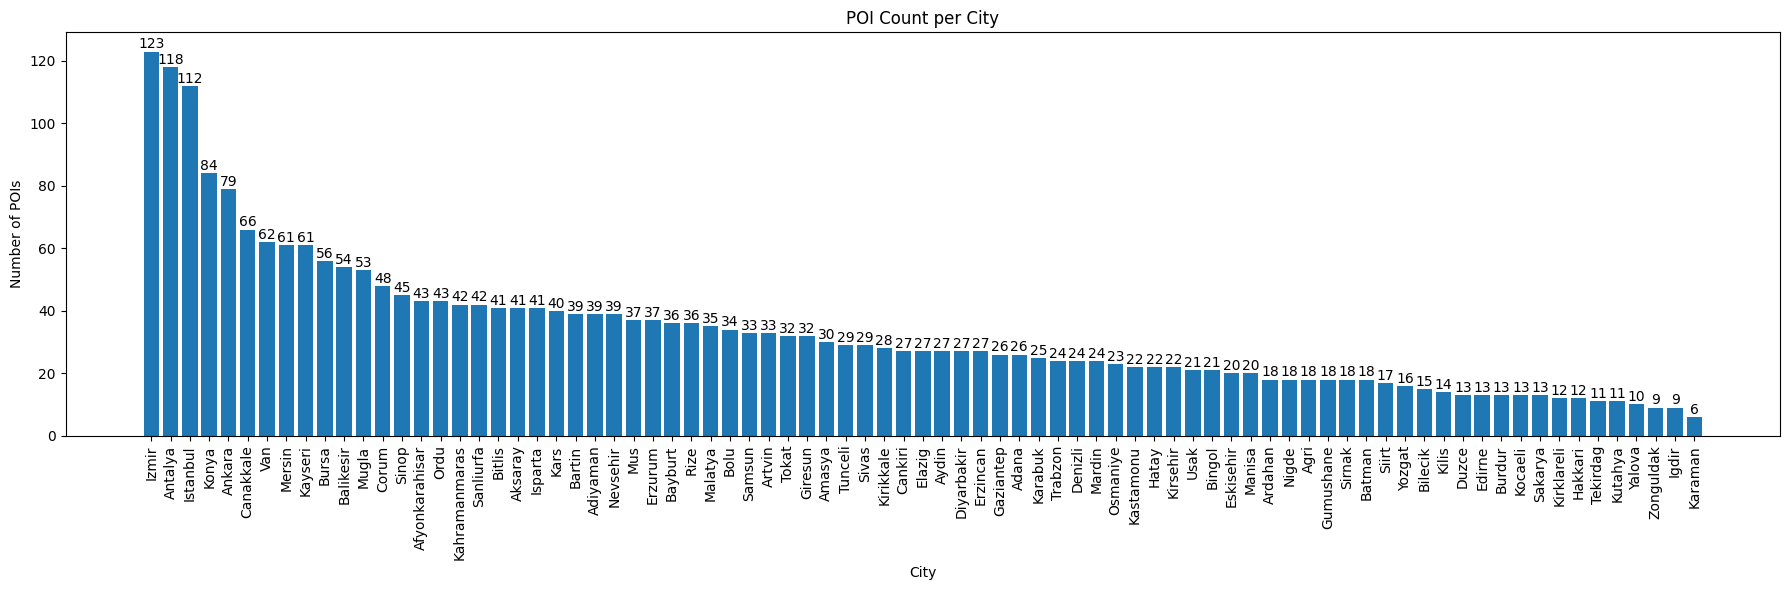

In [ ]:
# Bar chart of POI count per city, sorted descending. Each bar
# is labelled with its count for readability.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/poi_dataset_final.csv")

city_counts = df["city"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(18,6))
plt.bar(city_counts.index, city_counts.values)

plt.xticks(rotation=90)
plt.xlabel("City")
plt.ylabel("Number of POIs")
plt.title("POI Count per City")

# Write the numeric count just above each bar.
for i, v in enumerate(city_counts.values):
    plt.text(i, v + 1, str(v), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# Assign a `max_days` column representing how many days of sightseeing
# each city can reasonably sustain, derived from its POI count via a
# hand-tuned step function.

import pandas as pd

df = pd.read_csv("/content/poi_dataset_final.csv")

city_counts = df["city"].value_counts()

# Step function: more POIs -> more recommended days, capped at 8.
# Thresholds are empirical and intended to be comfortable rather than exhaustive.
def max_days_from_poi(poi_count):

    if poi_count <= 9:
        return 1
    elif poi_count <= 18:
        return 2
    elif poi_count <= 30:
        return 3
    elif poi_count <= 45:
        return 4
    elif poi_count <= 63:
        return 5
    elif poi_count <= 81:
        return 6
    elif poi_count <= 100:
        return 7
    else:
        return 8


# Build city -> max_days lookup and join it onto the dataframe.
city_to_max_days = {
    city: max_days_from_poi(count)
    for city, count in city_counts.items()
}

df["max_days"] = df["city"].map(city_to_max_days)

df.to_csv(
    "/content/poi_dataset_final_with_days.csv",
    index=False
)

print("Saved -> poi_dataset_final_with_days.csv")

Saved -> poi_dataset_final_with_days.csv


In [ ]:
# Estimate each city's min and max realistic travel distance by
# sampling lots of random 4-to-9-stop routes, solving each with a
# greedy nearest-neighbour heuristic, and reporting the low / high
# ends of the resulting distance distribution (converted from great-
# circle to road distance with a 1.65 multiplier).

import pandas as pd
import random
import math
import numpy as np

df = pd.read_csv("/content/poi_dataset_final.csv")

# Great-circle distance between two lat/lon points in kilometres.
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(math.radians,[lat1,lon1,lat2,lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat/2)**2 +
        math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    )

    c = 2 * math.asin(math.sqrt(a))

    return R * c


# Greedy TSP heuristic: start from the first point and repeatedly
# jump to the nearest unvisited one. Fast and good enough for small k.
def nearest_neighbor_route(points):

    remaining = points.copy()

    route = [remaining.pop(0)]

    while remaining:

        last = route[-1]

        next_point = min(
            remaining,
            key=lambda p: haversine(last[0], last[1], p[0], p[1])
        )

        route.append(next_point)

        remaining.remove(next_point)

    return route


# Sum of leg distances along an ordered route.
def route_distance(route):

    dist = 0

    for i in range(len(route)-1):

        dist += haversine(
            route[i][0], route[i][1],
            route[i+1][0], route[i+1][1]
        )

    return dist


results = []

cities = df["city"].unique()

# For each city with enough POIs, run Monte Carlo sampling.
for city in cities:

    city_df = df[df["city"] == city]

    pois = list(zip(city_df["lat"], city_df["lon"]))

    poi_count = len(pois)

    # Skip cities with fewer than 4 POIs — no meaningful route to sample.
    if poi_count < 4:
        continue

    # Sample size scales with POI count so bigger cities get better coverage.
    sample_size = max(500, poi_count * 5000)

    distances = []

    for _ in range(sample_size):

        # Each sample is a random 4-to-9-stop route.
        k = random.randint(4, min(9, poi_count))

        route_points = random.sample(pois, k)

        route = nearest_neighbor_route(route_points)

        d = route_distance(route)

        distances.append(d)

    distances.sort()

    # "Min" = mean of the 25 shortest routes (robust to outliers).
    # "Max" = 95th percentile (ignore pathological long tails).
    min_air = np.mean(distances[:25])
    max_air = np.percentile(distances,95)

    # 1.65x is a rough great-circle-to-road correction factor.
    min_d = min_air * 1.65
    max_d = max_air * 1.65

    # Round to the nearest 5 km on each side for cleaner downstream bounds.
    min_d = int(math.floor(min_d/5)*5)
    max_d = int(math.ceil(max_d/5)*5)

    results.append((city, poi_count, sample_size, min_d, max_d))


# Dump the table as a pipe-delimited text file — easy to diff / inspect.
with open("city_distance_ranges.txt","w",encoding="utf-8") as f:

    f.write("City | POI Count | Monte Carlo Samples | Min Distance | Max Distance\n\n")

    for r in sorted(results):

        f.write(
            f"{r[0]} | {r[1]} | {r[2]} | {r[3]} km | {r[4]} km\n"
)

In [ ]:
# Merge the city-level min/max distance ranges back onto every POI
# row so the final CSV carries per-row min/max distance columns.

import pandas as pd

# POI-level CSV with the max_days column already attached.
poi_df = pd.read_csv("poi_dataset_final_with_days.csv")

# Pipe-delimited distance table written in the previous cell.
distance_df = pd.read_csv("city_distance_ranges.txt", sep="|")

# csv sep="|" leaves padding whitespace on column names and cells.
poi_df.columns = poi_df.columns.str.strip()
distance_df.columns = distance_df.columns.str.strip()

# Strip whitespace from every string cell too.
distance_df = distance_df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Remove the " km" suffix so the values become numeric.
distance_df["Min Distance"] = distance_df["Min Distance"].str.replace(" km","").astype(float)
distance_df["Max Distance"] = distance_df["Max Distance"].str.replace(" km","").astype(float)

# Left join: every POI gets its city's distance range; POIs in cities
# that had fewer than 4 POIs (skipped by the Monte Carlo step) will
# have NaN here, which is fine.
merged_df = poi_df.merge(
    distance_df[["City","Min Distance","Max Distance"]],
    left_on="city",
    right_on="City",
    how="left"
)

# Rename to snake_case to match the rest of the schema.
merged_df = merged_df.rename(columns={
    "Min Distance": "min_distance_km",
    "Max Distance": "max_distance_km"
})

# The duplicate "City" join column is now redundant.
merged_df = merged_df.drop(columns=["City"])

# Write the final, everything-attached CSV.
merged_df.to_csv("poi_dataset_final_w_days_and_distance.csv", index=False)

print("poi_dataset_final_w_days_and_distance.csv oluşturuldu.")

poi_dataset_final_w_days_and_distance.csv oluşturuldu.
